<a href="https://colab.research.google.com/github/VikiTarasova/melbourne_housing-DTA/blob/main/notebooks/melborurne_housing_DTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Melborurne-housing-DTA


## Перший огляд

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
url = "https://raw.githubusercontent.com/VikiTarasova/melbourne_housing-DTA/refs/heads/main/data/melb_data.csv"
df = pd.read_csv(url)

In [ ]:
# Розмір таблиці
df.shape

print("Розмір таблиці (рядки, стовпці):", df.shape)

Розмір таблиці (рядки, стовпці): (13580, 21)


In [ ]:
# Перші рядки
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [ ]:
# Описова статистика

df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [ ]:
# Пропуски (кількість)
df.isna().sum()


,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


In [ ]:

# Зведена таблиця (типи + пропуски)

info = pd.DataFrame({
    "тип": df.dtypes.astype(str),
    "пропусків_%": (df.isna().mean() * 100).round(2),
})

info = info.sort_values("пропусків_%", ascending=False)
info


,тип,пропусків_%
BuildingArea,float64,47.50
YearBuilt,float64,39.58
CouncilArea,object,10.08
Car,float64,0.46
Suburb,object,0.00
Price,float64,0.00
Type,object,0.00
Rooms,int64,0.00
Address,object,0.00
Distance,float64,0.00


In [ ]:
# Перевірка підозрілих значень

df.describe(include="all")

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
count,13580,13580,13580.000000,13580,1.358000e+04,13580,13580,13580,13580.000000,13580.000000,...,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,12211,13580.000000,13580.000000,13580,13580.000000
unique,314,13378,NaN,3,NaN,5,268,58,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,33,NaN,NaN,8,NaN
top,Reservoir,5 Margaret St,NaN,h,NaN,S,Nelson,27/05/2017,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Moreland,NaN,NaN,Southern Metropolitan,NaN
freq,359,3,NaN,9449,NaN,9022,1565,473,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1163,NaN,NaN,4695,NaN
mean,NaN,NaN,2.937997,NaN,1.075684e+06,NaN,NaN,NaN,10.137776,3105.301915,...,1.534242,1.610075,558.416127,151.967650,1964.684217,NaN,-37.809203,144.995216,NaN,7454.417378
std,NaN,NaN,0.955748,NaN,6.393107e+05,NaN,NaN,NaN,5.868725,90.676964,...,0.691712,0.962634,3990.669241,541.014538,37.273762,NaN,0.079260,0.103916,NaN,4378.581772
min,NaN,NaN,1.000000,NaN,8.500000e+04,NaN,NaN,NaN,0.000000,3000.000000,...,0.000000,0.000000,0.000000,0.000000,1196.000000,NaN,-38.182550,144.431810,NaN,249.000000
25%,NaN,NaN,2.000000,NaN,6.500000e+05,NaN,NaN,NaN,6.100000,3044.000000,...,1.000000,1.000000,177.000000,93.000000,1940.000000,NaN,-37.856822,144.929600,NaN,4380.000000
50%,NaN,NaN,3.000000,NaN,9.030000e+05,NaN,NaN,NaN,9.200000,3084.000000,...,1.000000,2.000000,440.000000,126.000000,1970.000000,NaN,-37.802355,145.000100,NaN,6555.000000
75%,NaN,NaN,3.000000,NaN,1.330000e+06,NaN,NaN,NaN,13.000000,3148.000000,...,2.000000,2.000000,651.000000,174.000000,1999.000000,NaN,-37.756400,145.058305,NaN,10331.000000


## Очищення

In [ ]:
# копія датасету
clean = df.copy()

In [ ]:
# Видалення технічних / зайвих колонок

clean = clean.drop(columns=[col for col in clean.columns if "Unnamed" in col])

In [ ]:
# Перетворення дати

clean["Date"] = pd.to_datetime(clean["Date"], dayfirst=True)

In [ ]:
# Нулі як пропуски (логічно неможливі значення)
import numpy as np

zero_as_missing_cols = ["Landsize", "BuildingArea", "Car"]

for col in zero_as_missing_cols:
    if col in clean.columns:
        clean.loc[clean[col] == 0, col] = np.nan


In [ ]:
# Фізично неможливі значення (YearBuilt)

clean.loc[(clean["YearBuilt"] < 1800) | (clean["YearBuilt"] > 2026), "YearBuilt"] = np.nan


In [ ]:
#  Дублікаті

print("Дублікатів:", clean.duplicated().sum())

# Пропуски (перевірка після очищення)

print(clean.isna().sum().sort_values(ascending=False))


Дублікатів: 0
BuildingArea     6467
YearBuilt        5376
Landsize         1939
CouncilArea      1369
Car              1088
Price               0
Type                0
Rooms               0
Address             0
Suburb              0
Method              0
Date                0
SellerG             0
Bathroom            0
Bedroom2            0
Postcode            0
Distance            0
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64


## Дослідження (EDA)

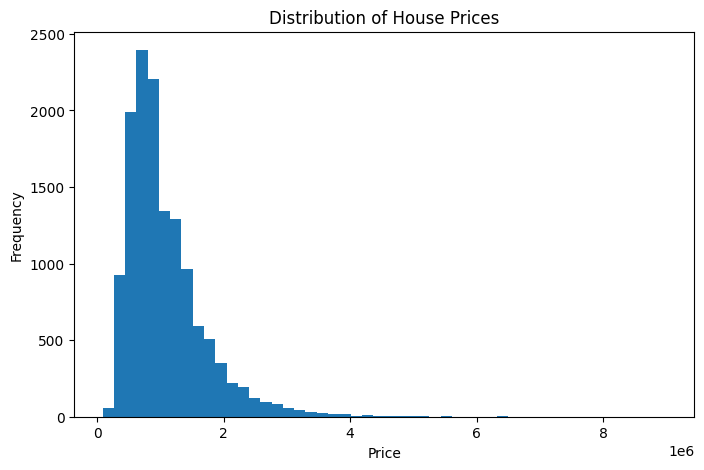

In [ ]:
# Гістограма ціни

plt.figure(figsize=(8,5))

plt.hist(clean["Price"], bins=50)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")

plt.show()

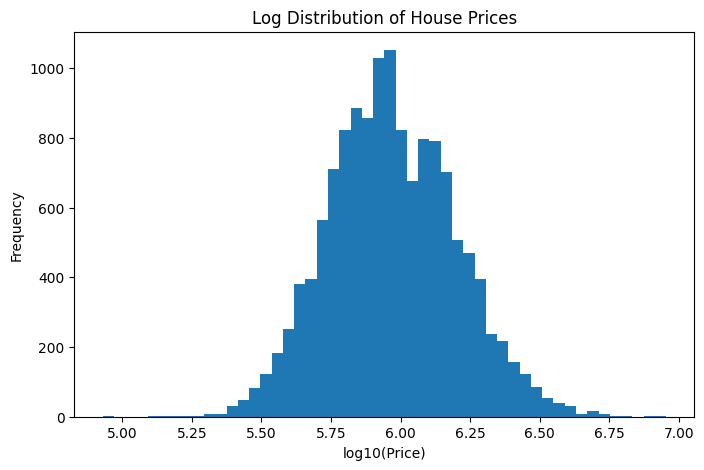

In [ ]:
# Логарифм ціни (для порівняння)

plt.figure(figsize=(8,5))

plt.hist(np.log10(clean["Price"]), bins=50)

plt.xlabel("log10(Price)")
plt.ylabel("Frequency")
plt.title("Log Distribution of House Prices")

plt.show()

<Figure size 800x500 with 0 Axes>

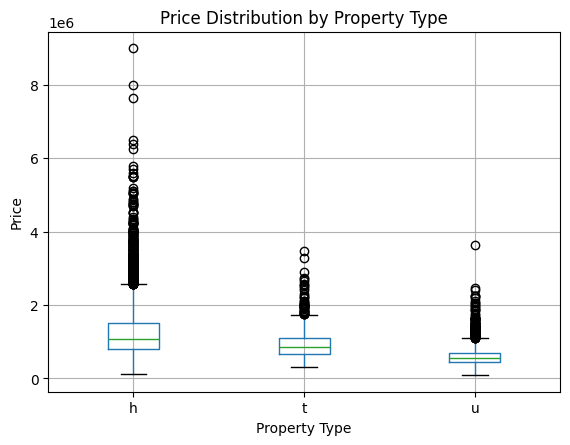

In [ ]:
# Ціна залежно від типу житла

plt.figure(figsize=(8,5))

clean.boxplot(
    column="Price",
    by="Type"
)

plt.xlabel("Property Type")
plt.ylabel("Price")
plt.title("Price Distribution by Property Type")

plt.suptitle("")

plt.show()

<Figure size 1200x500 with 0 Axes>

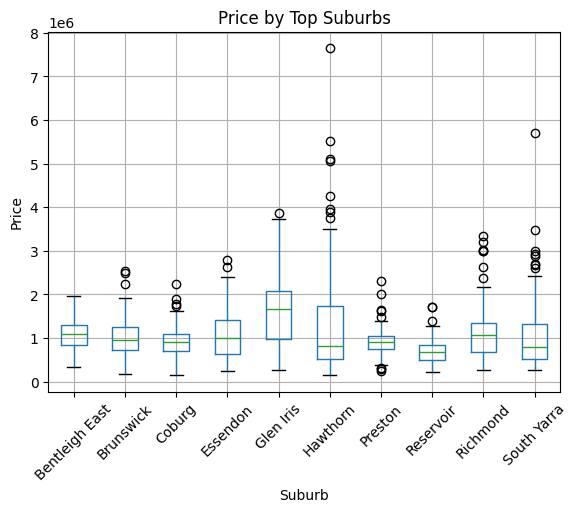

In [ ]:
# Ціна залежно від району (Suburb)

# Топ районів за кількістю об'єктів

top_suburbs = clean["Suburb"].value_counts().head(10).index


suburb_price = clean[
    clean["Suburb"].isin(top_suburbs)
]


plt.figure(figsize=(12,5))

suburb_price.boxplot(
    column="Price",
    by="Suburb",
    rot=45
)

plt.xlabel("Suburb")
plt.ylabel("Price")
plt.title("Price by Top Suburbs")

plt.suptitle("")

plt.show()

In [ ]:
# Кореляція числових ознак з Price

# тільки числові колонки

num = clean.select_dtypes("number")


# кореляція з Price

cor_price = num.corr()["Price"].drop("Price")


print(
    cor_price
    .sort_values(key=abs, ascending=False)
    .round(3)
)

Rooms            0.497
Bedroom2         0.476
Bathroom         0.467
YearBuilt       -0.332
Car              0.280
Lattitude       -0.213
Longtitude       0.204
Distance        -0.163
Postcode         0.108
BuildingArea     0.092
Propertycount   -0.042
Landsize         0.023
Name: Price, dtype: float64


In [ ]:
# Кореляційна матриця

corr_matrix = num.corr()
corr_matrix.round(2)

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
Rooms,1.00,0.50,0.29,0.06,0.94,0.59,0.41,0.00,0.12,-0.07,0.02,0.10,-0.08
Price,0.50,1.00,-0.16,0.11,0.48,0.47,0.28,0.02,0.09,-0.33,-0.21,0.20,-0.04
Distance,0.29,-0.16,1.00,0.43,0.30,0.13,0.21,0.01,0.10,0.25,-0.13,0.24,-0.05
Postcode,0.06,0.11,0.43,1.00,0.06,0.11,0.04,0.03,0.06,0.04,-0.41,0.45,0.06
Bedroom2,0.94,0.48,0.30,0.06,1.00,0.58,0.41,0.00,0.12,-0.05,0.02,0.10,-0.08
Bathroom,0.59,0.47,0.13,0.11,0.58,1.00,0.29,0.03,0.11,0.15,-0.07,0.12,-0.05
Car,0.41,0.28,0.21,0.04,0.41,0.29,1.00,0.01,0.10,-0.03,-0.00,0.04,-0.03
Landsize,0.00,0.02,0.01,0.03,0.00,0.03,0.01,1.00,0.50,0.08,0.01,0.01,-0.00
BuildingArea,0.12,0.09,0.10,0.06,0.12,0.11,0.10,0.50,1.00,0.02,0.04,-0.02,-0.03
YearBuilt,-0.07,-0.33,0.25,0.04,-0.05,0.15,-0.03,0.08,0.02,1.00,0.06,-0.00,0.01


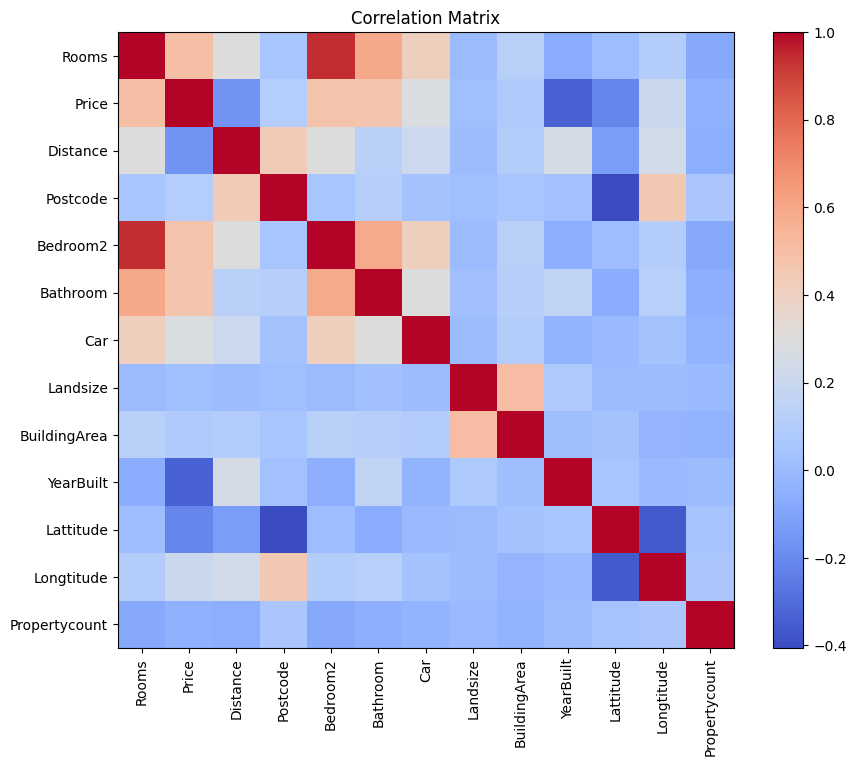

In [ ]:
plt.figure(figsize=(10,8))

plt.imshow(
    corr_matrix,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
clean[["Rooms","Bedroom2"]].corr()

,Rooms,Bedroom2
Rooms,1.00000,0.94419
Bedroom2,0.94419,1.00000


## Підготовка до моделювання

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# Цільова змінна

y = clean["Price"]

# Ознаки (усі інші)

X = clean.drop(columns=["Price"])


print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (13580, 20)
y shape: (13580,)


In [ ]:
# Числові ознаки

num_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Категоріальні ознаки

cat_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Числові колонки:")
print(num_cols)

print("\nКатегоріальні колонки:")
print(cat_cols)

Числові колонки:
['Rooms', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']

Категоріальні колонки:
['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'CouncilArea', 'Regionname']


In [ ]:
# Обробка числових колонок:
# пропуски заповнюємо медіаною

num_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])
# Обробка категоріальних колонок:
# пропуски -> найчастіше значення
# кодування One-Hot

cat_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [ ]:
preprocess = ColumnTransformer([

    (
        "num",
        num_pipeline,
        num_cols
    ),

    (
        "cat",
        cat_pipeline,
        cat_cols
    )
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (10864, 20)
Test: (2716, 20)


In [ ]:
# Навчання preprocessing тільки на train

X_train_ready = preprocess.fit_transform(X_train)

# Тест перетворюємо тим самим pipeline

X_test_ready = preprocess.transform(X_test)

print("Після preprocessing:")
print("Train:", X_train_ready.shape)
print("Test:", X_test_ready.shape)

Після preprocessing:
Train: (10864, 11342)
Test: (2716, 11342)


## Модель і прогноз

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [ ]:
def evaluate(model, name):

    # створюємо повний pipeline:
    # preprocessing + модель

    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

    # навчання тільки на train

    pipe.fit(
        X_train,
        y_train
    )

    # прогноз на тесті

    pred = pipe.predict(
        X_test
    )

    # метрики

    mae = mean_absolute_error(
        y_test,
        pred
    )
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    r2 = r2_score(
        y_test,
        pred
    )

    print(name)
    print("--------------------")
    print("MAE:", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R²:", round(r2, 3))
    print()

    return pipe

In [ ]:
baseline = evaluate(
    DummyRegressor(strategy="mean"),
    "Baseline model"
)

Baseline model
--------------------
MAE: 461257.73
RMSE: 630259.3
R²: -0.0



In [ ]:
linear_model = evaluate(
    LinearRegression(),
    "Linear Regression"
)

Linear Regression
--------------------
MAE: 256841.04
RMSE: 369210.18
R²: 0.657



In [ ]:
forest_model = evaluate(
    RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Random Forest"
)

Random Forest
--------------------
MAE: 162283.78
RMSE: 268723.81
R²: 0.818



In [ ]:
results = pd.DataFrame({

    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ]
})
results

,Model
0,Baseline
1,Linear Regression
2,Random Forest


In [ ]:
# отримуємо назви ознак після One-Hot Encoding

feature_names = (
    forest_model
    .named_steps["prep"]
    .get_feature_names_out()
)

# важливість ознак

importance = pd.DataFrame({

    "feature": feature_names,

    "importance":
        forest_model
        .named_steps["model"]
        .feature_importances_
})

importance = (
    importance
    .sort_values(
        "importance",
        ascending=False
    )
)

importance.head(10)

,feature,importance
11339,cat__Regionname_Southern Metropolitan,0.208469
0,num__Rooms,0.170326
1,num__Distance,0.129306
11046,cat__Type_u,0.085688
6,num__Landsize,0.067272
10,num__Longtitude,0.042946
7,num__BuildingArea,0.039734
9,num__Lattitude,0.026357
4,num__Bathroom,0.026034
8,num__YearBuilt,0.017659


Найбільший вплив на ціну житла має розташування (`Regionname`, `Distance`), що підтверджує важливість району та близькості до центру. Серед характеристик будинку найважливішими є кількість кімнат (`Rooms`), тип житла (`Type`) та площа ділянки (`Landsize`). Також модель враховує площу будівлі, кількість ванних кімнат, рік побудови та географічні координати.  

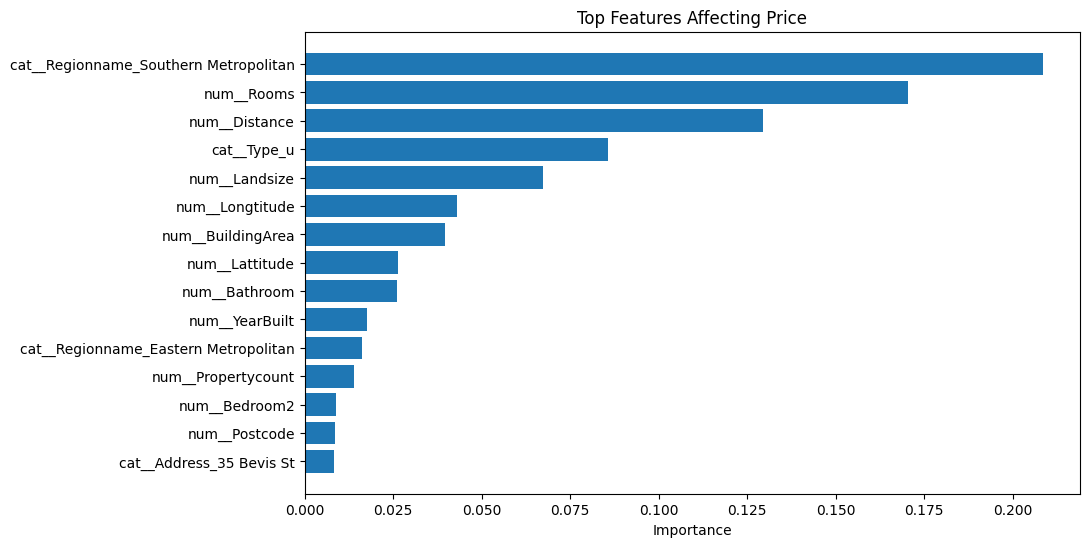

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(
    importance.head(15)["feature"],
    importance.head(15)["importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top Features Affecting Price")

plt.show()

In [ ]:
# один об'єкт
sample = X_test.iloc[[0]]

# реальна ціна
real_price = y_test.iloc[0]

# прогноз
prediction = forest_model.predict(sample)[0]
print("Реальна ціна:", round(real_price))
print("Прогноз моделі:", round(prediction))
print(
    "Різниця:",
    round(prediction - real_price)
)

Реальна ціна: 2600000
Прогноз моделі: 2060580
Різниця: -539420


**Висновок **

*   `Baseline` показує мінімальний рівень якості (просто середня ціна).  
*   `Linear Regression` дає покращення, бо враховує залежності між ознаками.  
*   `Random Forest` зазвичай працює краще, тому що враховує нелінійні залежності.  
*   Найважливіші ознаки показують, які характеристики найбільше впливають на ціну (наприклад, площа, кількість кімнат, район, відстань).


